In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [ ]:
#load dataset
df=pd.read_csv("/content/weather_forecast.csv")
df

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [ ]:
#understanding data
df.shape

(14, 5)

In [ ]:
df.columns

Index(['Outlook', 'Temperature', 'Humidity', 'Windy', 'Play'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     object
 2   Humidity     14 non-null     object
 3   Windy        14 non-null     object
 4   Play         14 non-null     object
dtypes: object(5)
memory usage: 692.0+ bytes


In [ ]:
df.describe()

,Outlook,Temperature,Humidity,Windy,Play
count,14,14,14,14,14
unique,3,3,2,2,2
top,Sunny,Mild,High,Weak,Yes
freq,5,6,7,8,9


In [ ]:
df.head()

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [ ]:
#Data Preprocessing
df.isnull().sum()

,0
Outlook,0
Temperature,0
Humidity,0
Windy,0
Play,0


In [ ]:
#convert categorical data to numbers
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])
df

,Outlook,Temperature,Humidity,Windy,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


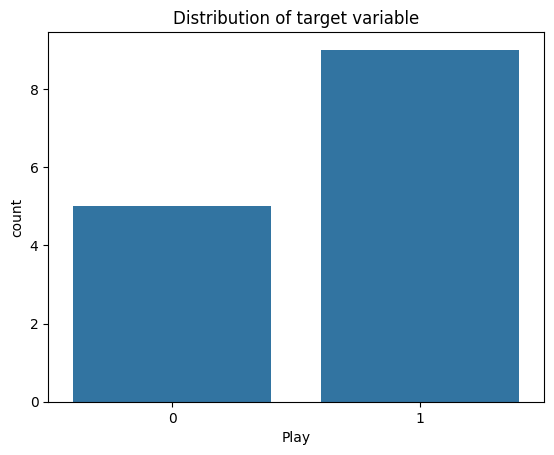

In [ ]:
#Exploratory Data Analysis(EDA)
#Distribution of target variable
sns.countplot(x='Play',data=df)
plt.title('Distribution of target variable')
plt.show()

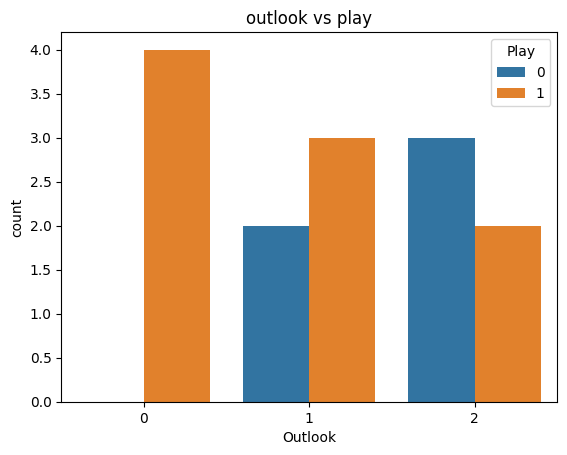

In [ ]:
#outlook vs play
sns.countplot(x='Outlook',hue='Play',data=df)
plt.title('outlook vs play')
plt.show()

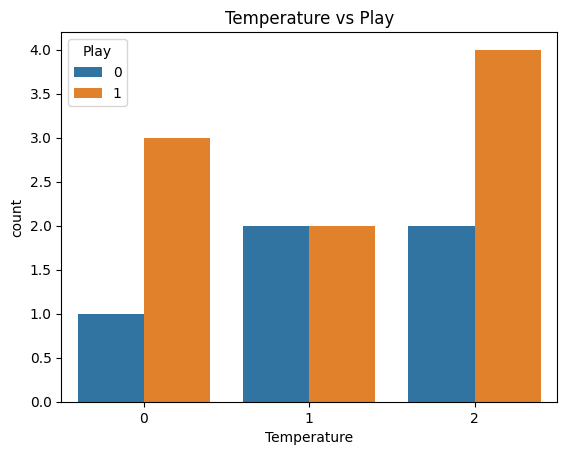

In [ ]:
#Temperature vs Play
sns.countplot(x='Temperature',hue='Play',data=df)
plt.title('Temperature vs Play')
plt.show()

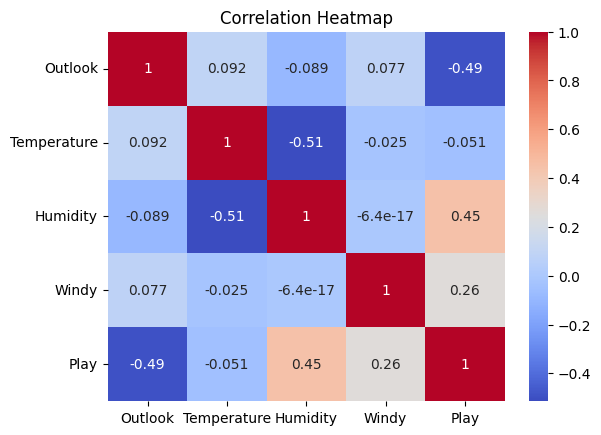

In [ ]:
#Correlation Heatmap
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#split Dataset
X=df.drop('Play',axis=1)
y=df['Play']

In [ ]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Decision Tree Model
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)
dt_pred=dt.predict(X_test)

In [ ]:
#Random Forecast Model
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

In [ ]:
#Model Evaluation
mae_dt=mean_absolute_error(y_test,dt_pred)
mae_rf=mean_absolute_error(y_test,rf_pred)
print("Decision Tree MAE:",mae_dt)
print("Random Forest MAE:",mae_rf)

Decision Tree MAE: 0.0
Random Forest MAE: 0.3333333333333333


In [ ]:
rmse_dt=np.sqrt(mean_squared_error(y_test,dt_pred))
rmse_rf=np.sqrt(mean_squared_error(y_test,rf_pred))
print("Decision Tree RMSE:",rmse_dt)
print("Random Forest RMSE:",rmse_rf)

Decision Tree RMSE: 0.0
Random Forest RMSE: 0.5773502691896257


In [ ]:
#Model Comparison
print("Decision Tree Accuracy:",dt.score(X_test,y_test))
print("Random Forest Accuracy:",rf.score(X_test,y_test))

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 0.6666666666666666


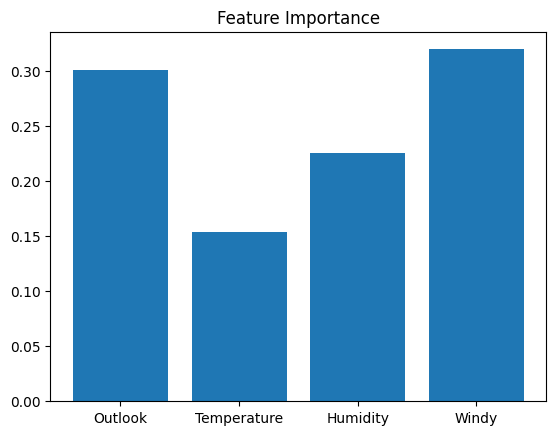

In [ ]:
#Visualization of Feature Importance
importance=rf.feature_importances_
plt.bar(X.columns,importance)
plt.title('Feature Importance')
plt.show()